In [3]:
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
January = pd.read_csv('JC-201801-citibike-tripdata.csv')
February = pd.read_csv('JC-201802-citibike-tripdata.csv')
March = pd.read_csv('JC-201803-citibike-tripdata.csv')
April = pd.read_csv('JC-201804-citibike-tripdata.csv')
May = pd.read_csv('JC-201805-citibike-tripdata.csv')
June = pd.read_csv('JC-201806-citibike-tripdata.csv')
July = pd.read_csv('JC-201807-citibike-tripdata.csv')
August = pd.read_csv('JC-201808-citibike-tripdata.csv')
September = pd.read_csv('JC-201809-citibike-tripdata.csv')
October = pd.read_csv('JC-201810-citibike-tripdata.csv')
November = pd.read_csv('JC-201811-citibike-tripdata.csv')
December = pd.read_csv('JC-201812-citibike-tripdata.csv')

In [5]:
df_2018 = pd.concat([January, February, March, April, May, June, July, August, September, October, November, December], axis = 0)

In [6]:
df_2018['starttime'] = pd.to_datetime(df_2018['starttime'])

In [7]:
df_2018.sample(10)

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
9049,262,2018-12-17 08:34:39.949,2018-12-17 08:39:02.6370,3203,Hamilton Park,40.727596,-74.044247,3209,Brunswick St,40.724176,-74.050656,29301,Subscriber,1969,0
34464,93,2018-08-17 17:49:35.787,2018-08-17 17:51:09.7100,3275,Columbus Drive,40.718355,-74.038914,3187,Warren St,40.721124,-74.038051,29530,Subscriber,1995,1
9247,277,2018-06-15 12:54:55.610,2018-06-15 12:59:32.6130,3187,Warren St,40.721124,-74.038051,3272,Jersey & 3rd,40.723332,-74.045953,29285,Subscriber,1981,1
1327,546,2018-09-20 13:17:29.519,2018-09-20 13:26:35.8590,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,29666,Customer,1984,1
8379,1007,2018-12-03 14:20:39.656,2018-12-03 14:37:27.3540,3203,Hamilton Park,40.727596,-74.044247,3209,Brunswick St,40.724176,-74.050656,26290,Customer,1990,1
33443,1550,2018-05-26 23:54:13.640,2018-05-27 00:20:04.0270,3677,Glenwood Ave,40.727551,-74.071061,3202,Newport PATH,40.727224,-74.033759,33630,Subscriber,1993,1
27620,198,2018-06-17 13:52:16.906,2018-06-17 13:55:35.8450,3267,Morris Canal,40.712419,-74.038526,3183,Exchange Place,40.716247,-74.033459,29664,Subscriber,1990,2
10665,135,2018-03-01 19:46:28.494,2018-03-01 19:48:44.2550,3213,Van Vorst Park,40.718489,-74.047727,3186,Grove St PATH,40.719586,-74.043117,26174,Subscriber,1986,1
18134,161,2018-11-13 20:15:23.782,2018-11-13 20:18:05.3550,3272,Jersey & 3rd,40.723332,-74.045953,3203,Hamilton Park,40.727596,-74.044247,26268,Subscriber,1979,2
12766,331,2018-10-20 15:52:03.650,2018-10-20 15:57:35.1780,3195,Sip Ave,40.730743,-74.063784,3679,Bergen Ave,40.722104,-74.071455,29287,Subscriber,1986,1


In [8]:
weather_2018 = pd.read_csv('WeatherNYC_2018.csv')
weather_2018 = weather_2018.rename(columns={
    'temperature_2m (°C)' : 'temperature (°C)',
    'relative_humidity_2m (%)' : 'relative_humidity (%)',
    'wind_speed_10m (km/h)' : 'wind_speed (km/h)',
})
weather_2018['time'] = pd.to_datetime(weather_2018['time'])

In [9]:
weather_2018.head()

,time,temperature (°C),relative_humidity (%),wind_speed (km/h),precipitation (mm)
0,2018-01-01 00:00:00,-12.8,51,16.8,0.0
1,2018-01-01 01:00:00,-13.1,54,16.3,0.0
2,2018-01-01 02:00:00,-13.2,55,16.3,0.0
3,2018-01-01 03:00:00,-13.4,56,15.3,0.0
4,2018-01-01 04:00:00,-13.6,57,15.0,0.0


In [10]:
df_2018 = df_2018.sort_values('starttime')
weather_2018 = weather_2018.sort_values('time')

df_2018 = pd.merge_asof(df_2018, weather_2018,
                        left_on='starttime',
                        right_on='time',
                        direction='nearest')

In [11]:
df_2018 = df_2018.drop(columns='time')

In [12]:
Gender_Map = {0: 'Unknown', 1: 'Male', 2: 'Female'}
df_2018['gender'] = df_2018['gender'].map(Gender_Map)

In [13]:
df_2018.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,temperature (°C),relative_humidity (%),wind_speed (km/h),precipitation (mm)
0,132,2018-01-01 00:01:45.814,2018-01-01 00:03:58.4750,3186,Grove St PATH,40.719586,-74.043117,3211,Newark Ave,40.721525,-74.046305,29590,Subscriber,1964,Male,-12.8,51,16.8,0.0
1,560,2018-01-01 01:27:17.272,2018-01-01 01:36:37.8410,3276,Marin Light Rail,40.714584,-74.042817,3269,Brunswick & 6th,40.726012,-74.050389,29613,Subscriber,1989,Female,-13.1,54,16.3,0.0
2,294,2018-01-01 01:29:03.020,2018-01-01 01:33:57.8990,3195,Sip Ave,40.730743,-74.063784,3225,Baldwin at Montgomery,40.723659,-74.064194,31940,Subscriber,1994,Male,-13.1,54,16.3,0.0
3,197,2018-01-01 01:59:31.746,2018-01-01 02:02:48.9960,3211,Newark Ave,40.721525,-74.046305,3278,Monmouth and 6th,40.725685,-74.048790,31949,Subscriber,1964,Male,-13.2,55,16.3,0.0
4,932,2018-01-01 02:06:17.541,2018-01-01 02:21:50.0270,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,-74.032108,31929,Subscriber,1992,Male,-13.2,55,16.3,0.0


In [14]:
df_2018.head(50).to_csv('testowa.csv')
df_2018.to_csv('2018.csv')

In [15]:
df_2018['temperature (°C)'] = df_2018['temperature (°C)'].round()

In [20]:
df_2018

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,...,bikeid,usertype,birth year,gender,temperature (°C),relative_humidity (%),wind_speed (km/h),precipitation (mm),distance_km,velocity (km/h)
0,132,2018-01-01 00:01:45.814,2018-01-01 00:03:58.4750,3186,Grove St PATH,40.719586,-74.043117,3211,Newark Ave,40.721525,...,29590,Subscriber,1964,Male,-13.0,51,16.8,0.0,0.344425,9.39
1,560,2018-01-01 01:27:17.272,2018-01-01 01:36:37.8410,3276,Marin Light Rail,40.714584,-74.042817,3269,Brunswick & 6th,40.726012,...,29613,Subscriber,1989,Female,-13.0,54,16.3,0.0,1.421928,9.14
2,294,2018-01-01 01:29:03.020,2018-01-01 01:33:57.8990,3195,Sip Ave,40.730743,-74.063784,3225,Baldwin at Montgomery,40.723659,...,31940,Subscriber,1994,Male,-13.0,54,16.3,0.0,0.788433,9.65
3,197,2018-01-01 01:59:31.746,2018-01-01 02:02:48.9960,3211,Newark Ave,40.721525,-74.046305,3278,Monmouth and 6th,40.725685,...,31949,Subscriber,1964,Male,-13.0,55,16.3,0.0,0.507827,9.28
4,932,2018-01-01 02:06:17.541,2018-01-01 02:21:50.0270,3183,Exchange Place,40.716247,-74.033459,3199,Newport Pkwy,40.728745,...,31929,Subscriber,1992,Male,-13.0,55,16.3,0.0,1.394356,5.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353887,351,2018-12-31 22:13:51.867,2018-12-31 22:19:43.3290,3278,Monmouth and 6th,40.725685,-74.048790,3186,Grove St PATH,40.719586,...,29220,Subscriber,1987,Male,7.0,95,23.3,3.4,0.829775,8.51
353888,322,2018-12-31 22:14:36.247,2018-12-31 22:19:59.0270,3278,Monmouth and 6th,40.725685,-74.048790,3186,Grove St PATH,40.719586,...,29521,Customer,1990,Female,7.0,95,23.3,3.4,0.829775,9.28
353889,311,2018-12-31 23:02:34.302,2018-12-31 23:07:45.6570,3194,McGinley Square,40.725340,-74.067622,3679,Bergen Ave,40.722104,...,29286,Subscriber,1986,Male,7.0,95,26.3,3.9,0.483544,5.60
353890,313,2018-12-31 23:15:43.068,2018-12-31 23:20:56.8070,3640,Journal Square,40.733670,-74.062500,3281,Leonard Gordon Park,40.745910,...,29212,Subscriber,1989,Female,7.0,95,26.3,3.9,1.430533,16.45


In [21]:
Temperature_analyze = df_2018.groupby(['temperature (°C)', 'gender']).agg(
    median_tripduration = ('tripduration', 'median'),
    number_of_rides = ('tripduration', 'count'),
    median_velocity = ('velocity (km/h)', 'median'),
    median_distance = ('distance_km', 'median')
).reset_index()

In [22]:
Temperature_analyze = Temperature_analyze[Temperature_analyze['number_of_rides'] > 20].reset_index(drop=True)

In [23]:
Men_Women_Temperature_analyze = Temperature_analyze[Temperature_analyze['gender'] != 'Unknown']

In [24]:
Men_Women_Temperature_analyze

,temperature (°C),gender,median_tripduration,number_of_rides,median_velocity,median_distance
0,-14.0,Male,406.0,65,7.880,0.887327
1,-13.0,Male,354.0,61,7.940,0.682284
2,-12.0,Female,317.5,24,8.445,0.829775
3,-12.0,Male,324.5,120,8.855,0.753365
4,-11.0,Female,288.0,37,9.330,0.682284
...,...,...,...,...,...,...
127,32.0,Male,358.0,1436,9.465,0.884786
129,33.0,Female,399.0,117,8.060,0.777648
130,33.0,Male,382.0,360,9.335,0.889167
132,34.0,Female,372.5,78,8.890,0.884774


In [25]:
Men_Women_Temperature_analyze['median_distance'] = Men_Women_Temperature_analyze['median_distance'] * 1000

C:\Users\papio\AppData\Local\Temp\ipykernel_28252\335704571.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Men_Women_Temperature_analyze['median_distance'] = Men_Women_Temperature_analyze['median_distance'] * 1000


<Axes: xlabel='median_tripduration', ylabel='temperature (°C)'>

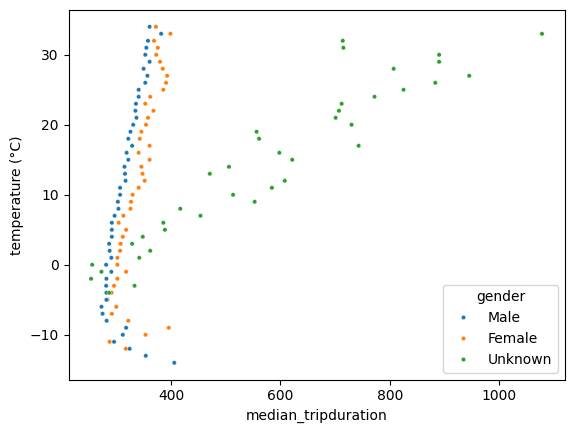

In [26]:
sns.scatterplot(
    x = 'median_tripduration',
    y = 'temperature (°C)',
    data = Temperature_analyze,
    hue = 'gender',
    s = 10
)

In [17]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c # wynik w km

df_2018['distance_km'] = haversine(
    df_2018['start station longitude'], df_2018['start station latitude'],
    df_2018['end station longitude'], df_2018['end station latitude']
)

In [18]:
df_2018['velocity (km/h)'] = (df_2018['distance_km'] / df_2018['tripduration'] * 3600).round(2)

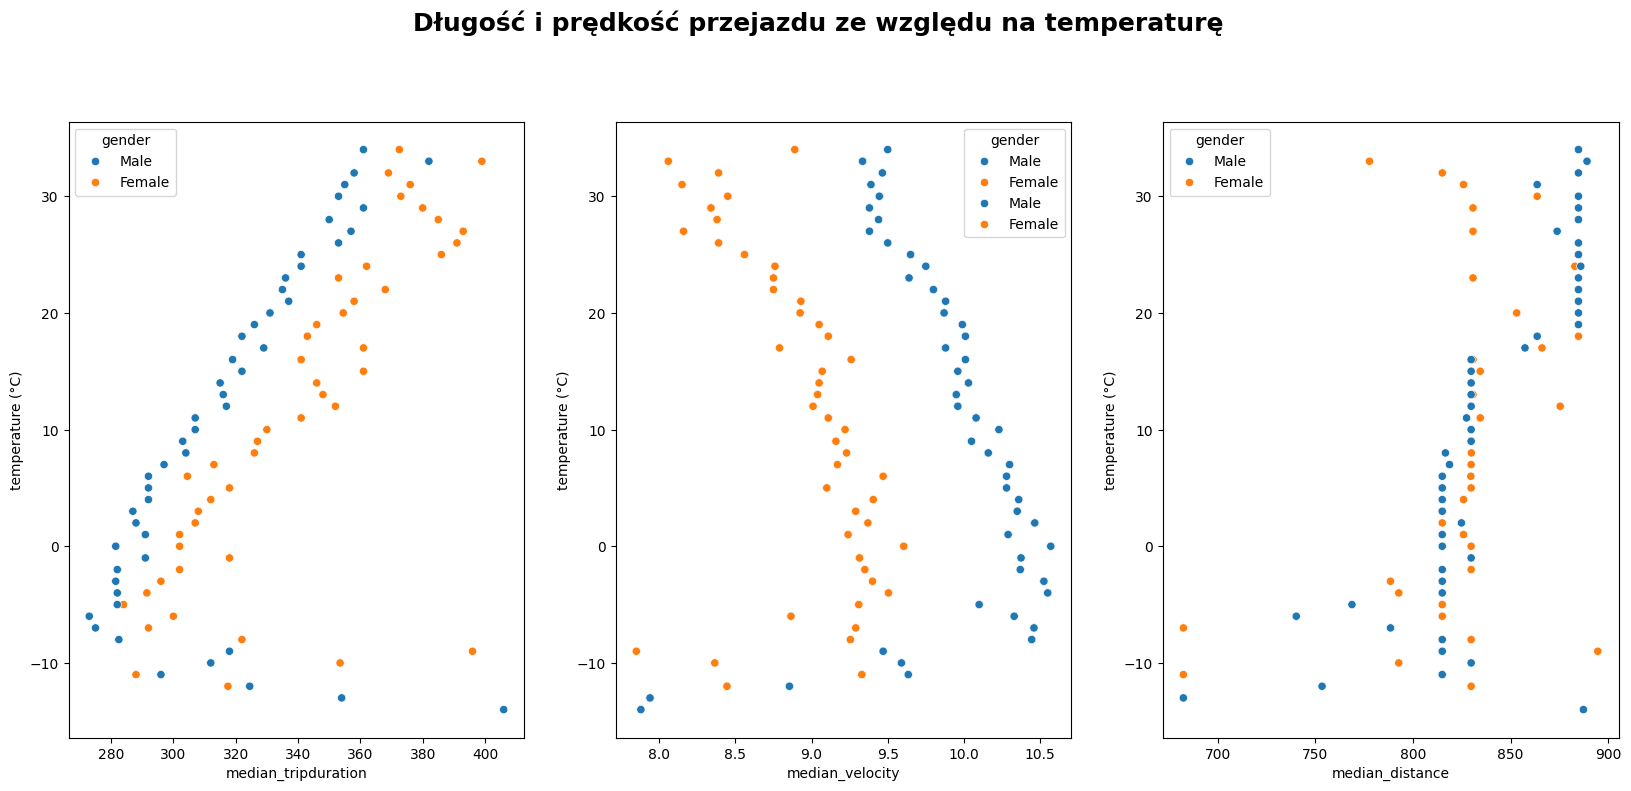

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Długość i prędkość przejazdu ze względu na temperaturę', 
             fontsize=18, fontweight='bold', y=1.02)

sns.scatterplot(
    x = 'median_tripduration',
    y = 'temperature (°C)',
    data = Men_Women_Temperature_analyze,
    hue = 'gender',
    ax=axes[0]
)

sns.scatterplot(
    x = 'median_velocity',
    y = 'temperature (°C)',
    data = Men_Women_Temperature_analyze,
    hue = 'gender',
    ax=axes[1]
)

sns.scatterplot(
    x = 'median_velocity',
    y = 'temperature (°C)',
    data = Men_Women_Temperature_analyze,
    hue = 'gender',
    ax=axes[1]
)

sns.scatterplot(
    x = 'median_distance',
    y = 'temperature (°C)',
    data = Men_Women_Temperature_analyze,
    hue = 'gender',
    ax=axes[2]
)

plt.savefig('Temperatura.png', dpi=300)

In [183]:
sns.scatterplot(
    x = 'median_tripduration',
    y = 'temperature (°C)',
    data = Men_Women_Temperature_analyze,
    hue = 'gender',
    ax=axes[0]
)

<Axes: xlabel='median_tripduration', ylabel='temperature (°C)'>

In [184]:
sns.scatterplot(
    x = 'median_velocity',
    y = 'temperature (°C)',
    data = Men_Women_Temperature_analyze,
    hue = 'gender',
    ax=axes[1]
)

<Axes: xlabel='median_velocity', ylabel='temperature (°C)'>

In [186]:
plt.show()

In [108]:
Precipitation_analyze

,precipitation (mm),gender,median_tripduration,number_of_rides
0,0.0,Female,349.0,62568
1,0.0,Male,320.0,213724
2,0.0,Unknown,653.0,17840
3,0.1,Female,347.5,4128
4,0.1,Male,327.0,13949
...,...,...,...,...
132,7.8,Male,302.5,28
133,9.3,Female,320.0,12
134,9.3,Male,382.5,32
135,9.6,Male,235.0,29


<Axes: xlabel='median_tripduration', ylabel='precipitation (mm)'>

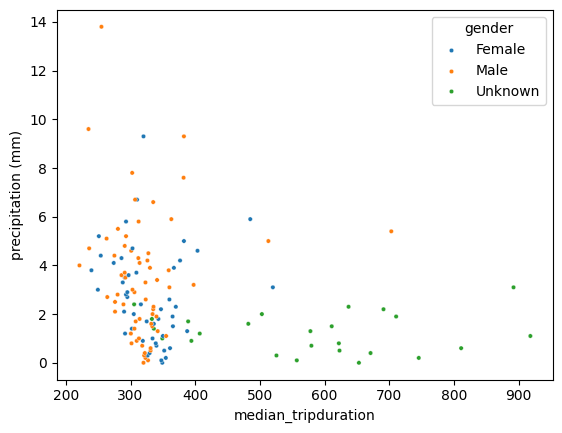

In [130]:
sns.scatterplot(
    x = 'median_tripduration',
    y = 'precipitation (mm)',
    data = Precipitation_analyze,
    hue='gender',
    s = 10
)